In [2]:
# I import my shared helpers, same module the other Gold notebooks used.
import cwt_utils as cwt
import importlib
importlib.reload(cwt)
import pandas as pd
import matplotlib.pyplot as plt

print("Silver dir exists:", cwt.SILVER_DIR.exists())
print("style_axes available:", hasattr(cwt, "style_axes"))

Silver dir exists: True
style_axes available: True


# Project 4 | NHS Data Engineering Portfolio | Yusuf Ismail
## NHS Cancer Waiting Times — Gold: The Door You Came In By (Article 3)

**Notebook 05 of 5** — Gold layer, third and final analytical cut.

This notebook answers the assumption I planted at the end of Article 2: does the way you are
referred change your wait? It does, and the direction is counterintuitive.

The Urgent Suspected Cancer route — the one a GP uses when they are most worried — is the
SLOWEST to treatment. The Consultant Upgrade route is the fastest. The route designed for
urgency performs worst on the urgency standard.

I compare 62-day compliance by referral route, nationally, across my 18 months.

**Input:** clean 62D Silver via cwt_utils
**Output:** Gold route table + chart for Article 3

**My analysis questions:**
1. How does 62-day compliance differ by referral route?
2. How big is the gap between the fastest and slowest route?
3. Why is the route built for urgency the one that performs worst — and what can the data
   NOT tell me about that?

## Analysis 1 — 62-day compliance by referral route

I compare the four referral routes on the 62-day standard, nationally, across my 18 months.
I use the England Total row, ALL CANCERS, ALL MODALITIES, so the routes are compared on the
same footing. The "ALL ROUTES" row is the blended average and I keep it only as a reference.

The question: does the way a patient enters the system change their odds of timely treatment?

In [6]:
# I load the 62D Silver file through my shared helper.
df62 = cwt.load_silver("62d")

# I isolate the national, like-for-like view: England Total, all cancers, all modalities,
# so the only thing varying between rows is the referral route.
by_route = df62[
    (df62["Org_Code"] == "Total") &
    (df62["Cancer_Type"] == "ALL CANCERS") &
    (df62["Treatment_Modality"] == "ALL MODALITIES")
].copy()

# I aggregate across the 18 months per route, then compute compliance from summed counts.
route_summary = by_route.groupby("referral_route_clean").agg(
    total_patients=("Total", "sum"),
    total_within=("Within", "sum"),
    total_breached=("After", "sum"),
).reset_index()
route_summary["compliance_pct"] = (route_summary["total_within"] / route_summary["total_patients"] * 100).round(1)

# I pull out the ALL ROUTES blended average as reference, then rank the real routes.
all_routes_avg = route_summary[route_summary["referral_route_clean"] == "ALL ROUTES"]["compliance_pct"].iloc[0]
ranked_routes = route_summary[route_summary["referral_route_clean"] != "ALL ROUTES"].sort_values("compliance_pct")

print(f"Blended average across all routes: {all_routes_avg}%\n")
print("--- 62-day compliance by referral route (worst to best) ---")
print(ranked_routes[["referral_route_clean", "total_patients", "total_breached", "compliance_pct"]].to_string(index=False))

# I state the gap between the fastest and slowest route — the Article 3 headline.
slowest = ranked_routes.iloc[0]
fastest = ranked_routes.iloc[-1]
print(f"\n--- The route gap ---")
print(f"Slowest route: {slowest['referral_route_clean']} — {slowest['compliance_pct']}%")
print(f"Fastest route: {fastest['referral_route_clean']} — {fastest['compliance_pct']}%")
print(f"Gap: {fastest['compliance_pct'] - slowest['compliance_pct']:.1f} percentage points")

Blended average across all routes: 67.4%

--- 62-day compliance by referral route (worst to best) ---
   referral_route_clean  total_patients  total_breached  compliance_pct
Urgent Suspected Cancer        293096.5        111280.0            62.0
              Screening         35892.0         12423.0            65.4
     Breast Symptomatic          2115.0           679.0            67.9
     Consultant Upgrade        153812.5         33585.0            78.2

--- The route gap ---
Slowest route: Urgent Suspected Cancer — 62.0%
Fastest route: Consultant Upgrade — 78.2%
Gap: 16.2 percentage points


## Chart — 62-day compliance by referral route

My Article 3 visual. I rank the four routes by 62-day compliance and annotate each with the
number of patients who came through it. The story the chart must tell: the Urgent Suspected
Cancer route is both the slowest AND the busiest. The system's main front door is its slowest one.

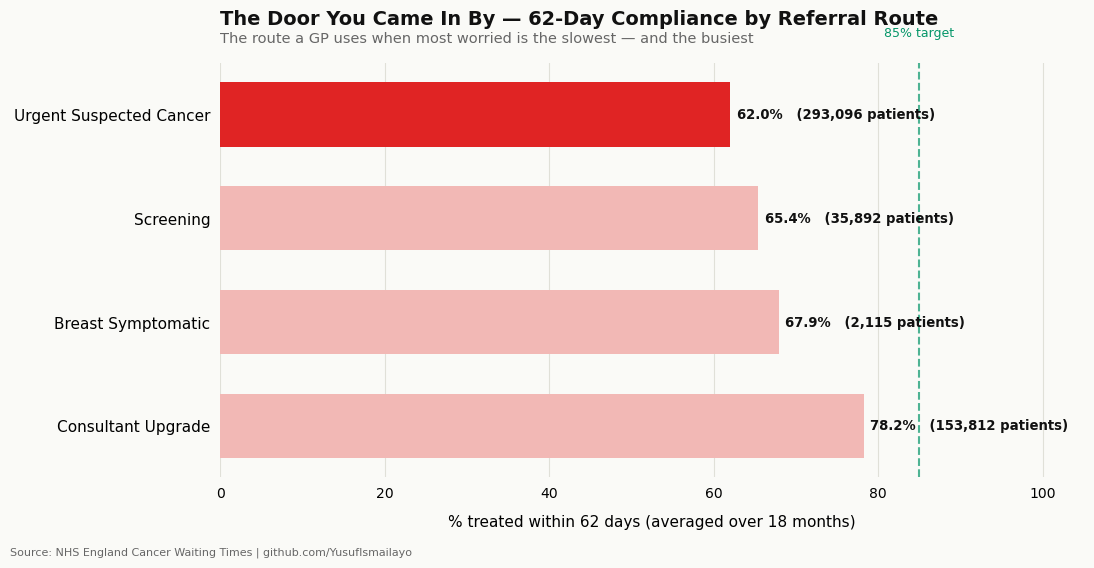

Chart saved: chart6_route_compliance.png


In [9]:
# I build the route compliance chart, worst to best.
chart_routes = ranked_routes.copy()

# I colour the slowest route (Urgent Suspected Cancer) in my standard red to anchor the eye,
# and the others in a muted tone, since the story is about that one route.
def route_colour(name):
    return cwt.RED if name == "Urgent Suspected Cancer" else "#F2B8B5"

colors = [route_colour(n) for n in chart_routes["referral_route_clean"]]

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor(cwt.BG)
cwt.style_axes(ax)
ax.xaxis.grid(True, color="#E0E0D8", linewidth=0.8, zorder=0)
ax.yaxis.grid(False)

y = range(len(chart_routes))
ax.barh(y, chart_routes["compliance_pct"], color=colors, height=0.62, zorder=3)
ax.set_yticks(y)
ax.set_yticklabels(chart_routes["referral_route_clean"], fontsize=11)
ax.invert_yaxis()  # worst at top

# I label each bar with compliance % and the patient volume that came through that route.
for i, row in enumerate(chart_routes.itertuples()):
    ax.text(row.compliance_pct + 0.8, i,
            f"{row.compliance_pct}%   ({row.total_patients:,.0f} patients)",
            va="center", ha="left", fontsize=9.5, fontweight="bold", color=cwt.INK)

# I mark the 85% target.
ax.axvline(85, color=cwt.GREEN, linewidth=1.5, linestyle="--", alpha=0.7, zorder=2)
ax.text(85, -0.75, "85% target", color=cwt.GREEN, fontsize=9, ha="center")

ax.set_xlim(0, 105)
ax.set_xlabel("% treated within 62 days (averaged over 18 months)", fontsize=11, labelpad=10)
ax.set_title("The Door You Came In By — 62-Day Compliance by Referral Route",
             fontsize=14, fontweight="bold", color=cwt.INK, pad=28, loc="left")
ax.text(0, 1.05, "The route a GP uses when most worried is the slowest — and the busiest",
        transform=ax.transAxes, fontsize=10.5, color=cwt.GREY)

cwt.source_note(fig, cwt.SOURCE_LINE)
plt.tight_layout()
plt.savefig(cwt.OUTPUTS_DIR / "chart6_route_compliance.png", dpi=180,
            bbox_inches="tight", facecolor=cwt.BG)
plt.show()
print("Chart saved: chart6_route_compliance.png")

## Step — Write Gold table for Article 3

I persist the route findings. Parquet for the pipeline, CSV for portability and the repo.

In [12]:
# I write the route compliance ranking.
route_out = ranked_routes.sort_values("compliance_pct").reset_index(drop=True).copy()
route_out.to_parquet(cwt.GOLD_DIR / "gold_62d_by_route.parquet", index=False)
route_out.to_csv(cwt.OUTPUTS_DIR / "gold_62d_by_route.csv", index=False)

print("Gold table written:")
print(f"  gold_62d_by_route.parquet   ({len(route_out)} rows)")
print(f"\nArticle 3 key figures locked:")
print(f"  Route gap: Consultant Upgrade {fastest['compliance_pct']}% vs "
      f"Urgent Suspected Cancer {slowest['compliance_pct']}% ({fastest['compliance_pct'] - slowest['compliance_pct']:.1f}pp)")
print(f"  Slowest route is also busiest: {slowest['total_patients']:,.0f} patients "
      f"({slowest['total_patients'] / route_summary[route_summary['referral_route_clean'] != 'ALL ROUTES']['total_patients'].sum() * 100:.0f}% of all)")
print(f"  Urgent Suspected Cancer breaches: {slowest['total_breached']:,.0f}")

Gold table written:
  gold_62d_by_route.parquet   (4 rows)

Article 3 key figures locked:
  Route gap: Consultant Upgrade 78.2% vs Urgent Suspected Cancer 62.0% (16.2pp)
  Slowest route is also busiest: 293,096 patients (60% of all)
  Urgent Suspected Cancer breaches: 111,280


In [1]:
# I confirm the route basis for the agent's "62-day combined" figure, and get the
# exact trust×month row count — one run answers both open questions.
import cwt_utils as cwt

df62 = cwt.load_silver("62d")

# I fix the two dimensions v1 scope locked, and leave route open to inspect.
base = df62[
    (df62["Cancer_Type"] == "ALL CANCERS") &
    (df62["Treatment_Modality"] == "ALL MODALITIES")
].copy()

# I ask which routes exist on this basis, and crucially how many have a real
# (non-null) compliance figure — a route that's all-null is no use as the headline.
print("Routes on the ALL CANCERS / ALL MODALITIES basis:")
print(base.groupby("referral_route_clean")["compliance_rate"]
          .agg(rows="size", populated="count").to_string())

# I count trust×month rows for the two candidate bases so I can compare like-for-like.
for route in ["ALL ROUTES", "Urgent Suspected Cancer"]:
    slice_ = base[base["referral_route_clean"] == route]
    trusts = slice_["Org_Code"].nunique()
    print(f"\n'{route}': {len(slice_):,} rows | "
          f"{trusts} distinct org codes (incl. Total) | "
          f"{slice_['period_month'].nunique()} months")

Routes on the ALL CANCERS / ALL MODALITIES basis:
                         rows  populated
referral_route_clean                    
ALL ROUTES               2659       2659
Breast Symptomatic       1136       1136
Consultant Upgrade       2550       2550
Screening                2275       2275
Urgent Suspected Cancer  2536       2536

'ALL ROUTES': 2,659 rows | 174 distinct org codes (incl. Total) | 18 months

'Urgent Suspected Cancer': 2,536 rows | 160 distinct org codes (incl. Total) | 18 months
